<a href="https://colab.research.google.com/github/Shiwampandeyofficial/CodeAlpha_EDA/blob/main/CodeAlpha_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape


(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


#Questions:-
1. *How many passengers survived and how many did not?*
2. *Who had a higher survival rate, males or females?*
3. *Which passenger class (1st, 2nd, 3rd) had the highest survival rate?*
4. *Did age affect the chances of survival?*
5. *Were passengers who paid higher fares more likely to survive?*

In [15]:

df = pd.read_csv(url)

df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.drop(columns=['Cabin'])
df = df.dropna(subset=['Embarked'])

print("Duplicates:", df.duplicated().sum())
df.isnull().sum()

Duplicates: 0


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


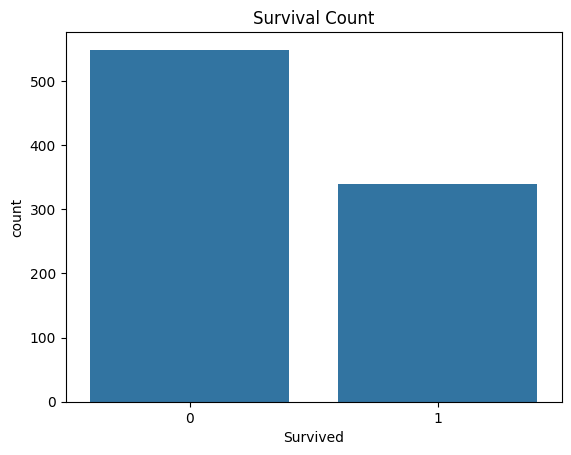

In [16]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

**Insight:**

> Out of 889 passengers, about 550 did not survive (Survived = 0) and about 340 survived (Survived = 1). Only around 38% of passengers survived the disaster.







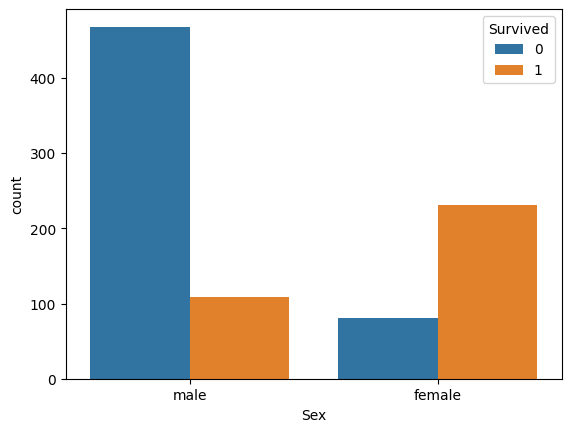

In [17]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

**Insight:**

> Males were the majority on board, and most of them (about 470) did not survive. Among females, about 230 survived versus only about 80 who did not. Women had a far higher survival rate than men, which fits the "women and children first" rule.



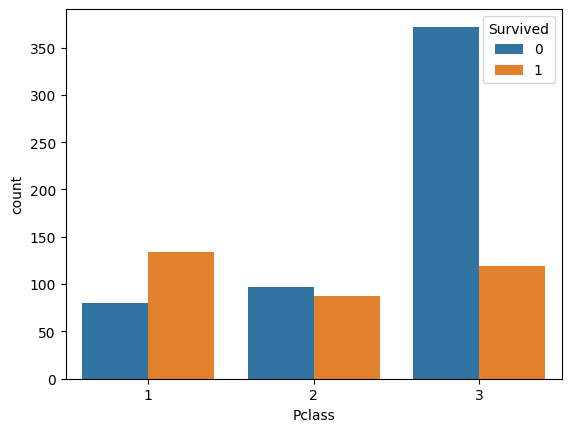

In [18]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

**Insight:**

> In 1st class, more passengers survived than died. In 2nd class, the numbers were almost equal. In 3rd class, about 370 passengers died versus about 120 who survived. Higher class meant a better chance of survival, and 3rd class was hit hardest.



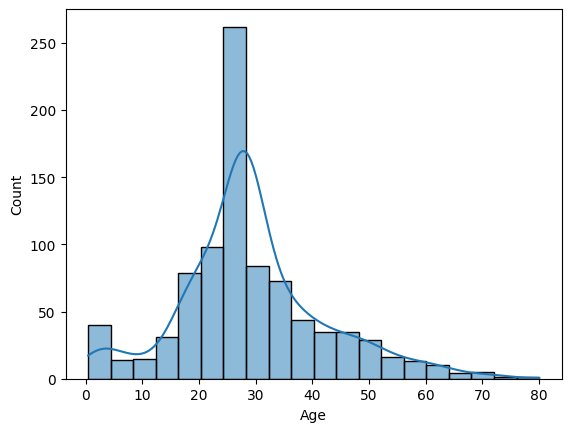

In [19]:
sns.histplot(df['Age'], bins=20, kde=True)
plt.show()

**Insight:**

> Most passengers were between 20 and 40 years old. There is a large spike around age 28 because missing ages were filled with the median value. There is also a small group of young children under 5, and very few passengers above 60.



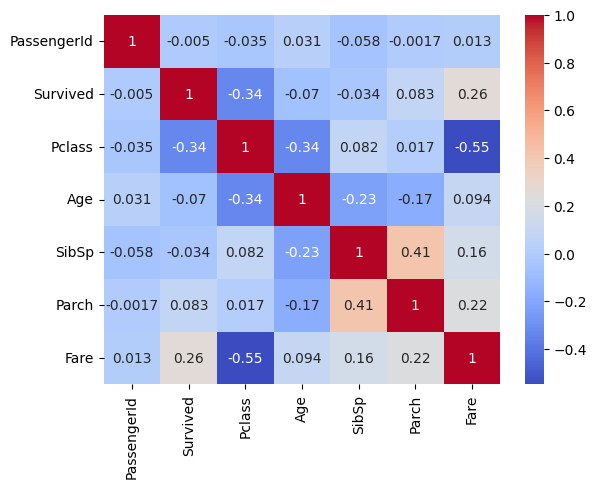

In [20]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()

**Insight:**

> Pclass has a negative correlation with Survived (-0.34), meaning lower class numbers (1st class) were linked to higher survival. Fare has a positive correlation with Survived (0.26), so higher fares meant better survival chances. Pclass and Fare are strongly negatively correlated (-0.55), as expected, since 1st class tickets cost more. Age has only a weak relationship with survival (-0.07).



#Conclusion

---

- Gender was the strongest factor in survival: women were far more likely to survive than men.
- Passenger class mattered: 1st class passengers had the best chances and 3rd class the worst.
- Higher fares were associated with higher survival, mainly because they reflect higher class.
- Age had only a weak effect on survival overall.
- The Cabin column was dropped because about 77% of its values were missing.